<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [2]:
# Check for GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

2.11.0+cpu


'cpu'

## 1. What are 3 areas in industry where computer vision is currently being used?

1. Robotics
2. Drones
3. Medical

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Overfitting in machine earning happens when a model performs extraordinarily well on training data but performs poorly on testing data. Mainly th model is not generalized and does not do well on unseen data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Train with more data.
2. Perform cross validation.
3. Perform feature selection to prevent multicollinearity.
4. Use dropout layers to randomly disable a percentage of neurons in each layer during deep learning training steps.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(f'Torch version: {torch.__version__}, Torchvision version: {torchvision.__version__}')

Torch version: 2.11.0+cpu, Torchvision version: 0.26.0+cpu


In [5]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    download = True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.32MB/s]


In [6]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [7]:
len(train_data), len(test_data)

(60000, 10000)

In [8]:
type(train_data[0]), type(test_data[0])

(tuple, tuple)

In [9]:
type(train_data[0][0]), type(train_data[0][1])

(torch.Tensor, int)

In [10]:
train_data[0][0].shape, train_data[0][1]

(torch.Size([1, 28, 28]), 5)

In [11]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [12]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '5')

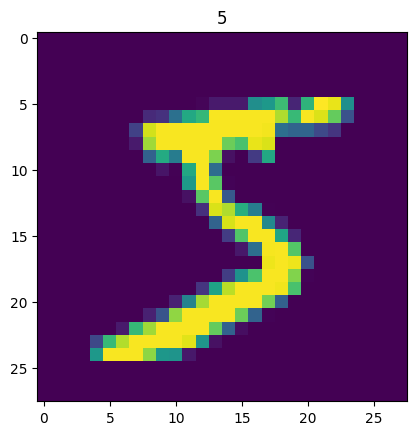

In [13]:
image, label = train_data[0]
print(f'Image shape: {image.shape}')
plt.imshow(image.squeeze())
plt.title(label)

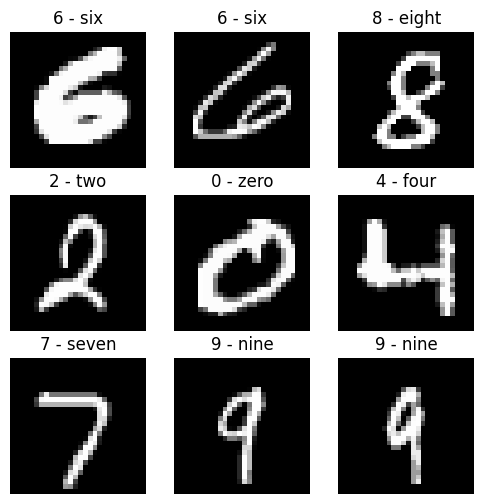

In [14]:
torch.manual_seed(42)
fig = plt.figure(figsize = (6, 6))
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap = 'gray')
  plt.title(class_names[label])
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)

len(train_dataloader), len(test_dataloader)

(1875, 313)

In [16]:
next(iter(train_dataloader))[0].shape, next(iter(train_dataloader))[1]

(torch.Size([32, 1, 28, 28]),
 tensor([5, 4, 4, 4, 1, 7, 0, 4, 6, 1, 2, 3, 5, 8, 5, 1, 5, 8, 1, 2, 3, 3, 1, 4,
         4, 4, 4, 4, 2, 9, 8, 4]))

In [17]:
next(iter(test_dataloader))[0].shape, next(iter(test_dataloader))[1]

(torch.Size([32, 1, 28, 28]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
         4, 0, 7, 4, 0, 1, 3, 1]))

In [18]:
data, label = next(iter(test_dataloader))
data.shape, label

(torch.Size([32, 1, 28, 28]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
         4, 0, 7, 4, 0, 1, 3, 1]))

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [19]:
class MNISTModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels = input_shape,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )
    )
    self.block_3 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 7 * 7, out_features = output_shape)
    )
  def forward(self, x: torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.block_3(x)
    return x

In [20]:
torch.manual_seed(42)
model_1 = MNISTModel(input_shape = 1, hidden_units = 10, output_shape = 10).to(device)
model_1, next(model_1.parameters()).device

(MNISTModel(
   (block_1): Sequential(
     (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (block_2): Sequential(
     (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (block_3): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=490, out_features=10, bias=True)
   )
 ),
 device(type='cpu'))

In [21]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [22]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [23]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               acc_fn = accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    train_pred = model(X)
    loss = loss_fn(train_pred, y)
    train_loss += loss
    train_acc += acc_fn(y_true = y, y_pred = train_pred.argmax(dim = 1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f'Train Loss: {train_loss:.5f} Train Accuracy: {train_acc:.2f}%\n')

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              acc_fn = accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for (X, y) in data_loader:
      X, y = X.to(device), y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += acc_fn(y_true = y, y_pred = test_pred.argmax(dim = 1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f'Test Loss: {test_loss:.5f} Test Accuracy: {test_acc:.2f}%\n')

In [24]:
from timeit import default_timer as timer
from tqdm import tqdm
torch.manual_seed(42)

epochs = 5

train_time_start_on_gpu = timer()

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n------------------')
  train_step(model = model_1, data_loader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer)
  test_step(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn)

train_time_end_on_gpu = timer()

total_train_time = train_time_end_on_gpu - train_time_start_on_gpu

print(f'Total train time on {device}: {total_train_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
------------------
Train Loss: 0.33561 Train Accuracy: 88.74%



 20%|██        | 1/5 [01:30<06:01, 90.45s/it]

Test Loss: 0.07362 Test Accuracy: 97.71%

Epoch: 1
------------------
Train Loss: 0.08217 Train Accuracy: 97.44%



 40%|████      | 2/5 [02:34<03:45, 75.15s/it]

...

Test Loss: 0.05947 Test Accuracy: 98.04%

Epoch: 3
------------------
Train Loss: 0.05594 Train Accuracy: 98.22%



 80%|████████  | 4/5 [04:43<01:07, 67.76s/it]

Test Loss: 0.06140 Test Accuracy: 97.92%

Epoch: 4
------------------
Train Loss: 0.04984 Train Accuracy: 98.42%



100%|██████████| 5/5 [05:45<00:00, 69.13s/it]

Test Loss: 0.04684 Test Accuracy: 98.39%

Total train time on cpu: 345.639 seconds


In [25]:
def eval_model(model: torch.nn.Module,
         data_loader: torch.utils.data.DataLoader,
         loss_fn: torch.nn.Module,
         acc_fn = accuracy_fn,
         device: torch.device = device):
  model.to(device)
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for (X, y) in data_loader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      loss += loss_fn(pred, y)
      acc += acc_fn(y_true = y, y_pred = pred.argmax(dim = 1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  print(f'Model name: {model.__class__.__name__} Model Loss: {loss:.5f} Model Accuracy: {acc:.2f}%')

In [26]:
torch.manual_seed(42)
eval_model(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn)

Model name: MNISTModel Model Loss: 0.04684 Model Accuracy: 98.39%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [27]:
classes = train_data.classes
classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [33]:
def prediction(model: torch.nn.Module, data: torch.utils.data.DataLoader, classes = classes, device: torch.device = device):
  data = data.to(device)
  model = model.to(device)
  pred = model(data.unsqueeze(dim = 0))
  pred_prob = torch.softmax(pred.squeeze(), dim = 0)
  pred_idx = pred_prob.argmax(dim = 0)
  return classes[pred_idx]

In [34]:
prediction(model_1, train_data[0][0]), train_data[0][1]

('5 - five', 5)

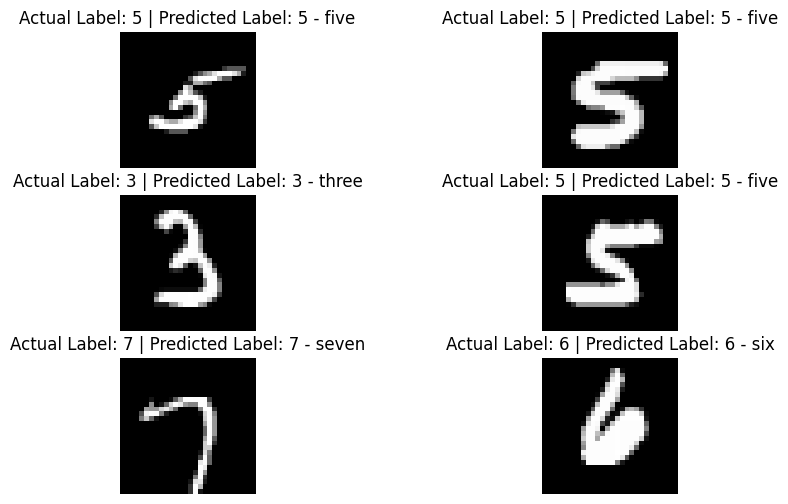

In [35]:
torch.manual_seed(42)
random_idx = torch.randint(len(test_data), size = [6, ])
cnt = 1
plt.figure(figsize = (10, 6))
for i in random_idx:
  idx = i.item()
  image, label = test_data[idx][0], test_data[idx][1]
  predicted_label = prediction(model_1, image)
  plt.subplot(3, 2, cnt)
  cnt += 1
  plt.title(f'Actual Label: {label} | Predicted Label: {predicted_label}')
  plt.imshow(image.squeeze(), cmap = 'gray')
  plt.axis(False)


## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [63]:
torch.manual_seed(42)
model_1.eval()
preds = []
with torch.inference_mode():
  for i in range(len(test_data)):
    image, label = test_data[i][0], test_data[i][1]
    pred = model_1(image.unsqueeze(dim = 0))
    pred_prob = torch.softmax(pred.squeeze(), dim = 0)
    pred_idx = pred_prob.argmax(dim = 0)
    preds.append(pred_idx.cpu())
preds = torch.tensor(preds)

In [41]:
!pip install torchmetrics; mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
import torchmetrics, mlxtend
print(f"mlxtend version: {mlxtend.__version__}")
print(f"torchmetrics version: {torchmetrics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.4 MB/s eta 0:00:00
/bin/bash: line 1: mlxtend: command not found
mlxtend version: 0.23.4
torchmetrics version: 1.9.0


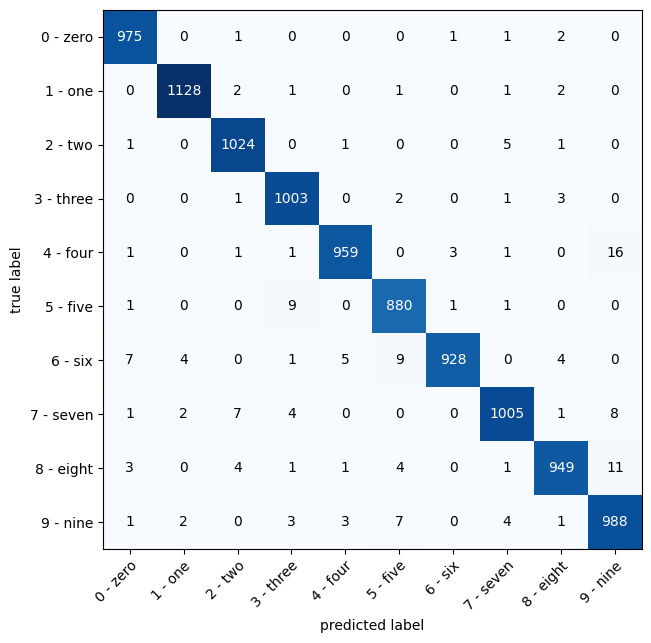

In [64]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes = len(classes), task = 'multiclass')
confmat_tensor = confmat(preds = preds, target = test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = classes,
    figsize = (10, 7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?